#NLP Mini Project
- **Name:** Hassaan Shaikh
- **UIN:** 242A007

#Topic: Sentiment Analysis on animated web series

##Preamble
Based on the content written in the first experiement of the NLP Lab manual, I have selected this topic. Given the increasing number of animated web series on the internet, both from independent inidviuals/teams and large media conglomerates alike, it is of the essence that a sentiment analysis model exists to help audiences and cerators alike make informed choices regarding the content they consume or create respectively.

This mini project aims to show a prototype of such a model that works on a limited dataset from two animated series—Hazbin Hotel and The Amazing Digital Circus—to analyze and train a model with and use this model to attempt to identify the sentiment of new opinions.
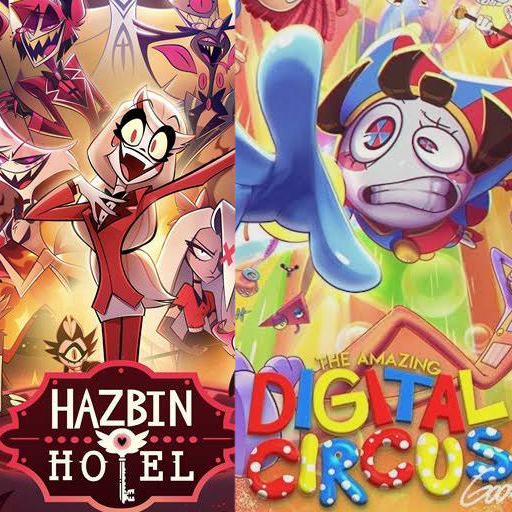

##Step 0: Exploratory Data Analysis
I put together a small dataset containing 175 entries for this sentiment analysis mini-project. This dataset contains a list of sentiments (labelled "tweets") on both shows and manually labelled as "Positive", "Negative" or "Neutral" based on thorough observation and my understanding of the sentiment behind each of them.

In [1]:
import nltk
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
sentiment_data = pd.read_csv('/content/Sentiment Collection.csv') # Don't forget to load the dataset into Colab beforehand
sentiment_data.head()

,series_name,tweet,sentiment
0,Hazbin Hotel,Good lord Hazbin Hotel/Helluva Boss fans are s...,Negative
1,Hazbin Hotel,We're slowly seeing this fandom descend into i...,Positive
2,Hazbin Hotel,extremely talented singers and song writers th...,Positive
3,Hazbin Hotel,"""Alastor doesn’t do well on camera!” Charlie c...",Positive
4,Hazbin Hotel,hazbin is probably one of the most larped show...,Neutral


In [3]:
sentiment_data.describe()

,series_name,tweet,sentiment
count,175,175,175
unique,2,175,3
top,Hazbin Hotel,Good lord Hazbin Hotel/Helluva Boss fans are s...,Positive
freq,100,1,88


In [4]:
sentiment_data.isna().any()

,0
series_name,False
tweet,False
sentiment,False


In [5]:
sentiment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   series_name  175 non-null    object
 1   tweet        175 non-null    object
 2   sentiment    175 non-null    object
dtypes: object(3)
memory usage: 4.2+ KB


In [6]:
sentiment_data['sentiment'].value_counts()

,count
sentiment,
Positive,88
Negative,51
Neutral,36


In [7]:
sentiment_data['series_name'].value_counts()

,count
series_name,
Hazbin Hotel,100
The Amazing Digital Circus,75


In [8]:
pd.crosstab(
    sentiment_data['series_name'],
    sentiment_data['sentiment']
)

sentiment,Negative,Neutral,Positive
series_name,,,
Hazbin Hotel,29,24,47
The Amazing Digital Circus,22,12,41


##Step 1: Data Preprocessing
Since we know what our three classes of sentiments are, we will encode them into numeric data and verify the encoding below.

In [9]:
sentiment_mapping = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

sentiment_data['sentiment_encoded'] = sentiment_data['sentiment'].map(sentiment_mapping)

In [10]:
sentiment_data[['sentiment', 'sentiment_encoded']].head()

,sentiment,sentiment_encoded
0,Negative,0
1,Positive,2
2,Positive,2
3,Positive,2
4,Neutral,1


The "series_name" column can also be encoded for use in more advanced, context-based sentiment models, but I am abstaining from using it for this prototype. For this prototype, the model will predict sentiment based solely on the textual content of the viewer's opinion, making the model applicable to comments about either series without requiring the series name as an input feature.

We will do some basic cleaning on the data like removing URLs, mentions, extra whitespaces, etc. We are not using Word Tokenizer, removing punctuation or stop words at this point as they can be helpful in sentiment analysis.

In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)             # Remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)        # Keep hashtag words
    text = re.sub(r'\s+', ' ', text).strip()     # Normalize whitespace
    return text

sentiment_data['clean_tweet'] = sentiment_data['tweet'].apply(clean_text)

In [12]:
sentiment_data[['tweet', 'clean_tweet']].head(10)

,tweet,clean_tweet
0,Good lord Hazbin Hotel/Helluva Boss fans are s...,good lord hazbin hotel/helluva boss fans are s...
1,We're slowly seeing this fandom descend into i...,we're slowly seeing this fandom descend into i...
2,extremely talented singers and song writers th...,extremely talented singers and song writers th...
3,"""Alastor doesn’t do well on camera!” Charlie c...","""alastor doesn’t do well on camera!” charlie c..."
4,hazbin is probably one of the most larped show...,hazbin is probably one of the most larped show...
5,It just looks very unfinished to me because I ...,it just looks very unfinished to me because i ...
6,Hazbin Hotel And Helluva Boss Crossing Over Wi...,hazbin hotel and helluva boss crossing over wi...
7,Alastor talking through his teeth is one of th...,alastor talking through his teeth is one of th...
8,why is hazbin hotel so afraid of making the ch...,why is hazbin hotel so afraid of making the ch...
9,Not my fault prime gives more to slop like Haz...,not my fault prime gives more to slop like haz...


##Step 2: Train-Test Split
Here, we will train and test our model.

In [13]:
X = sentiment_data['clean_tweet']
y = sentiment_data['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In the above code, `stratify=y` is used because we have 175 entries in the dataset and it makes the train-test split preserve approximately the same Positive/Negative/Neutral proportions in both sets.

##Step 3: TF-IDF Vectorization
Since the model cannot simply understand "The animation was fantastic", we need to turn the text into numerical features, therefore, the use of TF-IDF.



In [14]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train) # Fitting on training data
X_test_tfidf = tfidf.transform(X_test)

In [15]:
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (140, 784)
Testing data shape: (35, 784)


##Step 4: Training the Classifier
We will use Logistic Regression as the classification algorithm. Logistic Regression is commonly used for classification tasks and estimates the probability of an input belonging to each class.

In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred = model.predict(X_test_tfidf)

##Step 5: Evaluation

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 57.14%


In [19]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Neutral', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.50      0.30      0.38        10
     Neutral       0.00      0.00      0.00         7
    Positive       0.59      0.94      0.72        18

    accuracy                           0.57        35
   macro avg       0.36      0.41      0.37        35
weighted avg       0.44      0.57      0.48        35



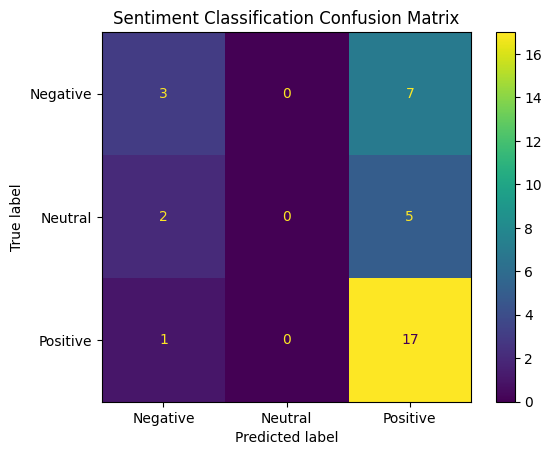

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Negative', 'Neutral', 'Positive']
)

plt.title("Sentiment Classification Confusion Matrix")
plt.show()

You may have noticed the disproportionate amount of Positives in the confusion matrix after training and evaluation. This is because finding tweets that are actually negative or neutral turned out to be genuinely harder than I expected.

##And now, we get to the good stuff!
This mini-project is about the model predicting the sentiment of each individual "tweet". We will use Python's input function to enter text from the user.

In [21]:
def predict_sentiment(text):
    cleaned_text = clean_text(text)
    text_tfidf = tfidf.transform([cleaned_text])
    prediction = model.predict(text_tfidf)[0]

    sentiment_labels = {
        0: 'Negative',
        1: 'Neutral',
        2: 'Positive'
    }

    return sentiment_labels[prediction]

In [22]:
predict_sentiment("The animation was absolutely fantastic!")

'Positive'

In [23]:
predict_sentiment("I hate you abel.")

'Negative'

Dataset Limitation: The dataset contains only 175 manually labelled entries. Furthermore, obtaining a balanced number of positive, negative, and neutral opinions proved challenging, resulting in a disproportionate number of positive examples. Consequently, the trained model may exhibit bias toward the majority class and may incorrectly classify some inputs. The model should therefore be considered a prototype demonstrating the application of NLP-based sentiment analysis rather than a production-ready system.

##Interactive Sentiment Analysis Prototype

The trained model can now be used to analyze previously unseen text. An interactive interface is provided so that a user can enter a comment and receive the model's predicted sentiment.

In [24]:
# The below code only works in Google Colab
import ipywidgets as widgets
from IPython.display import display, clear_output

text_input = widgets.Textarea(
    placeholder='Enter a comment or opinion...',
    description='Input:',
    layout=widgets.Layout(width='80%', height='100px')
)

analyze_button = widgets.Button(
    description='Analyze Sentiment',
    button_style='primary'
)

output = widgets.Output()

def analyze_text(button):
    with output:
        clear_output()

        text = text_input.value.strip()

        if not text:
            print("Please enter some text.")
            return

        sentiment = predict_sentiment(text)

        print(f"Predicted Sentiment: {sentiment}")

analyze_button.on_click(analyze_text)

display(text_input, analyze_button, output)

Textarea(value='', description='Input:', layout=Layout(height='100px', width='80%'), placeholder='Enter a comm…

Button(button_style='primary', description='Analyze Sentiment', style=ButtonStyle())

Output()